<font size="+3">ESMFold2 benchmark on TCR:epitope interactions</font> <br>

In [96]:
import glob
import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.decomposition import PCA

from Bio.PDB import PDBParser, NeighborSearch, PDBIO, Superimposer, MMCIFParser
from Bio.SeqUtils import seq1



# Benchmark

In [54]:
topdirs = ['benchmark', 'benchmark-msa']
batches = ['positives', 'negatives']

for topdir in topdirs:
    lst = []
    for batch in batches:
        df_input = pd.read_csv(f'{topdir}/{batch}/AF3_class_I.csv')
        df_output = pd.read_csv(f'{topdir}/{batch}/output.csv')
        df_output.columns = df_output.columns.str.lower()

        df = pd.merge(df_input, df_output, on='id')
        if batch == 'positives':
            df['label'] = 1
        else:
            df['label'] = 0
        lst.append(df)

    df = pd.concat(lst)
    df['epitope'] = df['MHC_allele_a'].str[4:] + '_' + df['peptide']
    df.to_csv(f'{topdir}/output.csv')

In [55]:
# af3 benchmark
topdir = '../260609_af3_benchmark_mod_template_search/standard'
df = pd.read_csv(f'{topdir}/AF3_class_I_output.csv')
df['label'] = np.where(df['batch'] == 'positives', 1, 0)
df = df.drop(columns=['batch'])
df = df.rename(columns={'AF3_iptm_pair_mean':'iptm_pair_mean'})
df.to_csv(f'{topdir}/output.csv')

benchmark
            epitope       auc     auc01
0  A0101_TTDPSFLGRY  0.700800  0.617895
1   A0201_GILGFVFTL  0.912500  0.794298
2   A0201_GLCTLVAML  0.846250  0.694298
3  A0201_LLAGIGTVPI  0.886200  0.776842
4   A0201_LLWNGPMAV  0.880833  0.846930
benchmark-msa
            epitope       auc     auc01
0  A0101_TTDPSFLGRY  0.769200  0.715789
1   A0201_GILGFVFTL  0.910833  0.858333
2   A0201_GLCTLVAML  0.797500  0.683333
3  A0201_LLAGIGTVPI  0.854200  0.656842
4   A0201_LLWNGPMAV  0.912292  0.839254
../260609_af3_benchmark_mod_template_search/standard
            epitope     auc     auc01
0  A0101_TTDPSFLGRY  0.7692  0.570526
1   A0201_GILGFVFTL  0.8574  0.793684
2   A0201_GLCTLVAML  0.8198  0.686316
3  A0201_LLAGIGTVPI  0.8618  0.658947
4   A0201_LLWNGPMAV  0.8592  0.764211


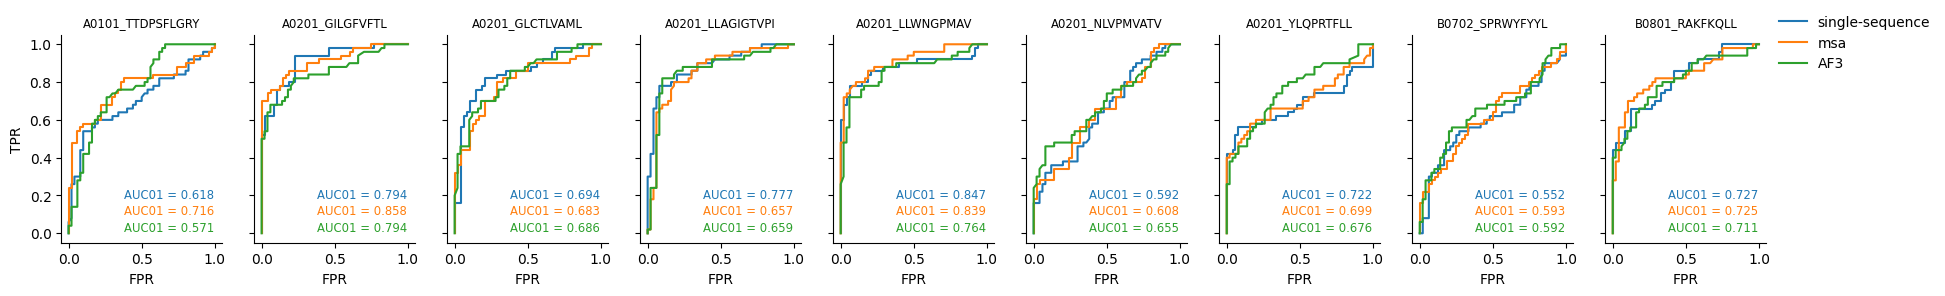

In [56]:
fig, axes = plt.subplots(1, 9, figsize=(22, 2.7), sharex=True, sharey=True)

topdirs = ['benchmark', 'benchmark-msa', '../260609_af3_benchmark_mod_template_search/standard']
labels_map = {
    'benchmark': 'single-sequence',
    'benchmark-msa': 'msa',
    '../260609_af3_benchmark_mod_template_search/standard': 'AF3',
}
colors = {
    'benchmark': 'C0',
    'benchmark-msa': 'C1',
    '../260609_af3_benchmark_mod_template_search/standard': 'C2',
}

legend_handles = []
legend_labels = []

for topdir in topdirs:
    df = pd.read_csv(f'{topdir}/output.csv')
    color = colors[topdir]

    topdir_records = []

    for cnt, (name, group) in enumerate(df.groupby('epitope')):
        ax = axes[cnt]

        y_true = group['label'].values
        y_scores = group['iptm_pair_mean'].values

        fpr, tpr, _ = roc_curve(y_true, y_scores)
        auc = roc_auc_score(y_true, y_scores)
        auc01 = roc_auc_score(y_true, y_scores, max_fpr=0.1)

        line, = ax.plot(fpr, tpr, color=color)

        ax.set_title(name, fontsize='small')

        # stack AUC01 labels for up to 3 topdirs without overlapping
        y_pos = 0.2 - 0.08 * topdirs.index(topdir)
        ax.text(0.95, y_pos, f"AUC01 = {auc01:.3f}", transform=ax.transAxes,
                ha='right', va='bottom', fontsize='small', color=color)

        ax.set_xlabel('FPR')
        if cnt == 0:
            ax.set_ylabel('TPR')

        topdir_records.append({'epitope': name, 'auc': auc, 'auc01': auc01})

        if cnt == 0:
            legend_handles.append(line)
            legend_labels.append(labels_map[topdir])

    df_auc = pd.DataFrame(topdir_records)
    df_auc.to_csv(f'{topdir}/output_auc.csv', index=False)
    print(topdir)
    print(df_auc.head())

sns.despine()
fig.legend(legend_handles, legend_labels, loc='upper left',
           bbox_to_anchor=(0.9, 1.0), frameon=False)

epitope
A0101_TTDPSFLGRY    0.617895
A0201_GILGFVFTL     0.794298
A0201_GLCTLVAML     0.694298
A0201_LLAGIGTVPI    0.776842
A0201_LLWNGPMAV     0.846930
A0201_NLVPMVATV     0.591579
A0201_YLQPRTFLL     0.722105
B0702_SPRWYFYYL     0.552193
B0801_RAKFKQLL      0.727193
Name: auc01, dtype: float64 epitope
A0101_TTDPSFLGRY    0.715789
A0201_GILGFVFTL     0.858333
A0201_GLCTLVAML     0.683333
A0201_LLAGIGTVPI    0.656842
A0201_LLWNGPMAV     0.839254
A0201_NLVPMVATV     0.608421
A0201_YLQPRTFLL     0.698947
B0702_SPRWYFYYL     0.592544
B0801_RAKFKQLL      0.725000
Name: auc01, dtype: float64
Index(['A0101_TTDPSFLGRY', 'A0201_GILGFVFTL', 'A0201_GLCTLVAML',
       'A0201_LLAGIGTVPI', 'A0201_LLWNGPMAV', 'A0201_NLVPMVATV',
       'A0201_YLQPRTFLL', 'B0702_SPRWYFYYL', 'B0801_RAKFKQLL'],
      dtype='object', name='epitope')
epitope
A0101_TTDPSFLGRY    0.617895
A0201_GILGFVFTL     0.794298
A0201_GLCTLVAML     0.694298
A0201_LLAGIGTVPI    0.776842
A0201_LLWNGPMAV     0.846930
A0201_NLVPMVATV     0

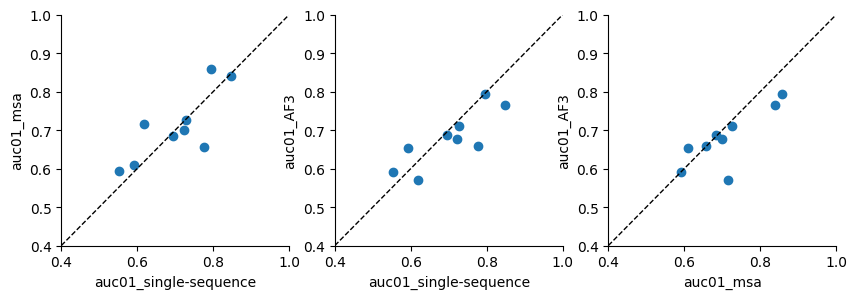

In [68]:
topdirs = {
    'single-sequence': 'benchmark',
    'msa': 'benchmark-msa',
    'AF3': '../260609_af3_benchmark_mod_template_search/standard',
}

# load each topdir's auc01 per epitope, indexed by epitope for easy joining
dfs = {}
for label, topdir in topdirs.items():
    d = pd.read_csv(f'{topdir}/output_auc.csv')
    dfs[label] = d.set_index('epitope')['auc01']

comparisons = [
    ('single-sequence', 'msa'),
    ('single-sequence', 'AF3'),
    ('msa', 'AF3'),
]

fig, axes = plt.subplots(1, 3, figsize=(10, 3))

for ax, (xlabel, ylabel) in zip(axes, comparisons):
    x = dfs[xlabel]
    y = dfs[ylabel]
    print(x,y)
    # align on shared epitopes only, in case sets differ
    common = x.index.intersection(y.index)
    print(common)
    x = x.loc[common]
    y = y.loc[common]
    
    ax.scatter(x, y)

    lims = [0.4, 1.0]  # adjust to your data range, or compute dynamically below
    ax.plot(lims, lims, 'k--', linewidth=1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)

    ax.set_xlabel(f'auc01_{xlabel}')
    ax.set_ylabel(f'auc01_{ylabel}')

sns.despine()

Friedman test: stat=2.889, p=0.2359


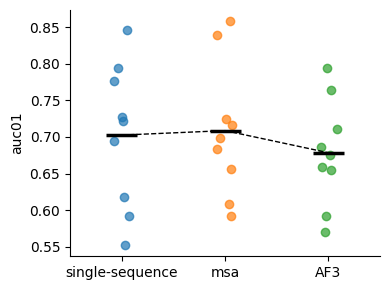

In [66]:
topdirs = {
    'single-sequence': 'benchmark',
    'msa': 'benchmark-msa',
    'AF3': '../260609_af3_benchmark_mod_template_search/standard',
}

dfs = {}
for label, topdir in topdirs.items():
    d = pd.read_csv(f'{topdir}/output_auc.csv')
    dfs[label] = d.set_index('epitope')['auc01']

groups = ['single-sequence', 'msa', 'AF3']

fig, ax = plt.subplots(figsize=(4, 3))

rng = np.random.default_rng(0)
jitter_width = 0.08

means = []

for i, label in enumerate(groups):
    y = dfs[label].values
    x = np.full(len(y), i) + rng.uniform(-jitter_width, jitter_width, size=len(y))

    ax.scatter(x, y, alpha=0.7, color=f'C{i}')

    mean_y = y.mean()
    means.append(mean_y)
    ax.hlines(mean_y, i - 0.15, i + 0.15, color='black', linewidth=2.5, zorder=3)

# dashed line connecting the means across groups
ax.plot(range(len(groups)), means, 'k--', linewidth=1, zorder=2)

ax.set_xticks(range(len(groups)))
ax.set_xticklabels(groups)
ax.set_ylabel('auc01')
ax.set_xlim(-0.5, len(groups) - 0.5)

sns.despine()
fig.tight_layout()

### stats ###
# Friedman test (non-parametric repeated-measures ANOVA) 
from scipy.stats import friedmanchisquare
common = dfs['single-sequence'].index.intersection(dfs['msa'].index).intersection(dfs['AF3'].index)
ss = dfs['single-sequence'].loc[common]

msa = dfs['msa'].loc[common]
af3 = dfs['AF3'].loc[common]

stat, p = friedmanchisquare(ss, msa, af3)
print(f"Friedman test: stat={stat:.3f}, p={p:.4f}")

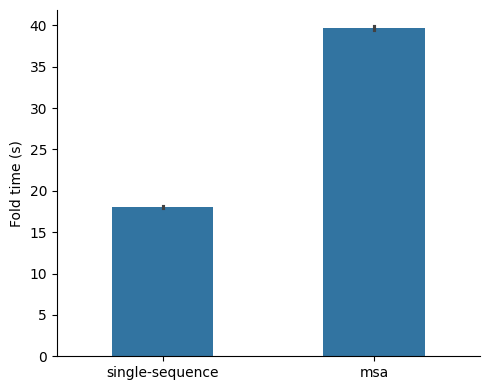

In [73]:
topdirs = ['benchmark', 'benchmark-msa']
labels_map = {'benchmark': 'single-sequence', 'benchmark-msa': 'msa'}
batches = ['positives', 'negatives']

all_dfs = []
for topdir in topdirs:
    lst = []
    for batch in batches:
        df = pd.read_csv(f'{topdir}/{batch}/output.csv')
        lst.append(df)
    df = pd.concat(lst)
    df['topdir'] = labels_map[topdir]  # use the display label directly
    all_dfs.append(df)

combined = pd.concat(all_dfs)

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(data=combined, x='topdir', y='fold_time_seconds', order=list(labels_map.values()), ax=ax, gap=0.4)

ax.set_xlabel('')
ax.set_ylabel('Fold time (s)')
sns.despine()
fig.tight_layout()

# Structural inspection

## Experimental structures to define reference space

In [89]:
def extract_cdr_coords(pdb_path, cdr_dict, chain_map={"TRA":"A","TRB":"B"}, cdr3_splits=None):
    """
    Extract Cα coordinates for CDRs.
    cdr_dict: {"CDR1A": seq, "CDR2A": seq, "CDR3A": seq, ...}
    cdr3_splits: optional {chain_label: {"cdr3v": seq, "cdr3j": seq}}
                 sub-segments are located by offset from the CDR3 position.
    """
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("pdb", pdb_path)
    cdr_coords = {}

    for chain_label, chain_id in chain_map.items():
        chain_obj = structure[0][chain_id]
        residues  = [res for res in chain_obj if res.id[0] == " " and "CA" in res]
        seq = "".join([seq1(res.get_resname()) for res in residues])
        cdr_coords[chain_label] = {}

        cdr3_start = cdr3_len = None
        for i, cdr_key in enumerate([f"CDR1{chain_label[-1]}", f"CDR2{chain_label[-1]}", f"CDR3{chain_label[-1]}"], 1):
            cdr_seq = cdr_dict[cdr_key].upper()
            idx = seq.find(cdr_seq)
            if idx == -1:
                print(f"Warning: {cdr_key} not found in chain {chain_id} of {pdb_path}")
                return None
            cdr_coords[chain_label][f"cdr{i}"] = np.array(
                [res["CA"].get_coord() for res in residues[idx:idx + len(cdr_seq)]]
            )
            if i == 3:
                cdr3_start, cdr3_len = idx, len(cdr_seq)

        # CDR3 sub-segments located by offset — no ambiguous search on short seqs
        if cdr3_splits and chain_label in cdr3_splits:
            for seg_name, seg_seq in cdr3_splits[chain_label].items():
                if not seg_seq:
                    continue
                if seg_name == 'cdr3v':
                    start = cdr3_start
                elif seg_name == 'cdr3j':
                    start = cdr3_start + cdr3_len - len(seg_seq)
                else:
                    continue
                cdr_coords[chain_label][seg_name] = np.array(
                    [res["CA"].get_coord() for res in residues[start:start + len(seg_seq)]]
                )

    return cdr_coords


def build_coord_matrix(cdr_coord_dict, min_cdr_lengths):
    """
    Build coordinate matrix with fixed-length CDRs.
    """
    coord_matrix = []
    for tcr, chains in cdr_coord_dict.items():
        vec = []
        for chain, cdrs in chains.items():
            for cdr_name in ["cdr1","cdr2"]:
                coords = cdrs[cdr_name]
                L = min_cdr_lengths[chain][cdr_name]
                # first 2 + last L-2
                selected = np.vstack([coords[:2], coords[-(L-2):]])
                vec.extend(selected.flatten())
            # CDR3: first 5 + last L-5
            coords = cdrs["cdr3"]
            L = min_cdr_lengths[chain]["cdr3"]
            selected = np.vstack([coords[:5], coords[-(L-5):]])
            vec.extend(selected.flatten())
        coord_matrix.append(vec)
    
    return np.array(coord_matrix)

In [ ]:
df = pd.read_csv('../260508_exp_structures_interactive/260305_data_structures_human.csv')
indir = '../260326_TCR_motif_atlas_exp_structures/pdbs_mhc_align'

pdbs = glob.glob(f'{indir}/*.pdb')
pdbs.sort()

pdbs = [p for p in pdbs if os.path.basename(p).split('.')[0] in df['PDB'].values]

cdr_coord_dict = {}
pdb_ids = []
for pdb_file in pdbs:
    pdb_id = os.path.basename(pdb_file).split('.')[0]

    # exctract CDR coordinates
    row = df[df["PDB"] == pdb_id]
    cdr_dict = {cdr: str(row[cdr].values[0]).upper() for cdr in ["CDR1A","CDR2A","CDR3A","CDR1B","CDR2B","CDR3B"]}
    cdr_coords = extract_cdr_coords(pdb_file, cdr_dict, chain_map={"TRA":"D","TRB":"E"})
    if cdr_coords is None:
        continue
    cdr_coord_dict[pdb_id] = cdr_coords
    pdb_ids.append(pdb_id)

print(len(pdbs))
print(len(cdr_coord_dict))
# minimal CDR lengths
min_cdr_lengths = {}
for chain_label in ["TRA","TRB"]:
    min_cdr_lengths[chain_label] = {}
    for cdr_name in ["cdr1","cdr2","cdr3"]:
        min_len = min(cdr_coord_dict[pdb_id][chain_label][cdr_name].shape[0] 
                    for pdb_id in cdr_coord_dict)
        min_cdr_lengths[chain_label][cdr_name] = min_len


# build coordinate matrix and perform pca
coord_matrix = build_coord_matrix(cdr_coord_dict, min_cdr_lengths)
coord_matrix = pd.DataFrame(coord_matrix)
coord_matrix.insert(0, 'PDB', pdb_ids)
coord_matrix.to_pickle('coord_matrix_exp.pkl')

with open("min_cdr_lengths_exp.pkl", "wb") as f:
    pickle.dump(min_cdr_lengths, f)

      PDB        Peptide       MHC        TRAV      TRBV MHC Class  \
0    1AO7      LLFGYPVYV     A0201    TRAV12-2   TRBV6-5      MHCI   
1    1BD2      LLFGYPVYV     A0201  TRAV29/DV5   TRBV6-5      MHCI   
2    1FYT  PKYVKQNTLKLAT  DRB10101     TRAV8-4    TRBV28     MHCII   
3    1J8H  PKYVKQNTLKLAT  DRB10401     TRAV8-4    TRBV28     MHCII   
4    1MI5      FLRGRAYGL     B0801    TRAV26-2   TRBV7-8      MHCI   
..    ...            ...       ...         ...       ...       ...   
219  9D95     YHLIVDTDSL     B3801      TRAV35  TRBV20-1      MHCI   
220  9GV7    SLAGGLDDMKA     A0201    TRAV12-2   TRBV6-3      MHCI   
221  9HLJ      KAYNVTQAF     C1202       TRAV5   TRBV7-8      MHCI   
222  9K2I      FSGEYIPTV     A0201    TRAV13-1   TRBV3-1      MHCI   
223  9WBD      SPRWYFYYL     B0702      TRAV25   TRBV7-8      MHCI   

         Species    TRAJ     TRBJ             CDR3A              CDR3B  \
0    HomoSapiens  TRAJ24  TRBJ2-7     CAVTTDSWGKLQF   CASRPGLAGGRPEQYF   
1    HomoSa

## Align predicted structures

In [101]:
chain_rename = {'MHC': 'A', 'B2M': 'B', 'PEPTIDE': 'C', 'TCRA': 'D', 'TCRB': 'E'}

parser = MMCIFParser(QUIET=True)
template = parser.get_structure('template', 'template-align.cif')
template_mhc = template[0]['MHC']
template_atoms = [res['CA'] for res in template_mhc if res.id[0] == ' ' and 'CA' in res]

topdirs = ['benchmark', 'benchmark-msa']

for topdir in topdirs:
    indir = f'{topdir}/positives/models'
    outdir = f'{topdir}/positives/models-align'
    os.makedirs(outdir, exist_ok=True)

    cif_files = sorted(glob.glob(f'{indir}/*.cif'))
    print(f'{topdir}: {len(cif_files)} files')

    for cif_path in cif_files:
        fname = os.path.basename(cif_path).replace('.cif', '.pdb')
        structure = parser.get_structure('model', cif_path)

        model_mhc = structure[0]['MHC']
        model_atoms = [res['CA'] for res in model_mhc if res.id[0] == ' ' and 'CA' in res]

        if len(model_atoms) != len(template_atoms):
            print(f'  Warning: {fname} MHC length mismatch ({len(model_atoms)} vs {len(template_atoms)}), skipping')
            continue

        sup = Superimposer()
        sup.set_atoms(template_atoms, model_atoms)
        sup.apply(structure[0].get_atoms())

        for chain in structure[0]:
            if chain.id in chain_rename:
                chain.id = chain_rename[chain.id]

        io = PDBIO()
        io.set_structure(structure)
        io.save(f'{outdir}/{fname}')

    print(f'  Saved to {outdir}')

benchmark: 450 files
  Saved to benchmark/positives/models-align
benchmark-msa: 450 files
  Saved to benchmark-msa/positives/models-align


In [110]:
with open("min_cdr_lengths_exp.pkl", "rb") as f:
    min_cdr_lengths = pickle.load(f)

topdirs = ['benchmark', 'benchmark-msa']

for topdir in topdirs:
    df = pd.read_csv(f'{topdir}/positives/AF3_class_I.csv')
    df = df.rename(columns={'cdr3_TRA':'CDR3A', 'cdr3_TRB':'CDR3B'})

    # annotate CDR1/2
    for gene in ['TRAV', 'TRBV']:
        ref = pd.read_csv(f'../MixTCRviz/data_raw/HomoSapiens/{gene}.csv')
        ref = ref.rename(columns={ref.columns[0]: gene})
        ref[f'CDR1{gene[-2]}'] = ref['CDR1'].str.replace('-', '', regex=False)
        ref[f'CDR2{gene[-2]}'] = ref['CDR2'].str.replace('-', '', regex=False)
        ref = ref[[gene, f'CDR1{gene[-2]}', f'CDR2{gene[-2]}']]
        df = pd.merge(df, ref, on=gene)

    print(df.head())
    indir = f'{topdir}/positives/models-align'

    pdbs = glob.glob(f'{indir}/*.pdb')
    pdbs.sort()

    pdbs = [p for p in pdbs if os.path.basename(p).split('.')[0] in df['id'].values]

    cdr_coord_dict = {}
    pdb_ids = []
    for pdb_file in pdbs:
        pdb_id = os.path.basename(pdb_file).split('.')[0]

        # exctract CDR coordinates
        row = df[df["id"] == pdb_id]
        cdr_dict = {cdr: str(row[cdr].values[0]).upper() for cdr in ["CDR1A","CDR2A","CDR3A","CDR1B","CDR2B","CDR3B"]}
        cdr_coords = extract_cdr_coords(pdb_file, cdr_dict, chain_map={"TRA":"D","TRB":"E"})
        if cdr_coords is None:
            continue
        cdr_coord_dict[pdb_id] = cdr_coords
        pdb_ids.append(pdb_id)

    # build coordinate matrix and perform pca
    coord_matrix = build_coord_matrix(cdr_coord_dict, min_cdr_lengths)
    coord_matrix = pd.DataFrame(coord_matrix)
    coord_matrix.insert(0, 'id', pdb_ids)
    coord_matrix.to_pickle(f'{topdir}/coord_matrix.pkl')

          id              CDR3A            CDR3B        TRAV    TRAJ  \
0  tcr_00001      CAAATDSWGKLQF  CASSLEQGLPHAQYF  TRAV29/DV5  TRAJ24   
1  tcr_00002       CAVTDSNYQLIW   CASRPPGADTEAFF      TRAV21  TRAJ33   
2  tcr_00003         CAGGADKLIF   CASSLRQGADTQYF      TRAV21  TRAJ34   
3  tcr_00004  CVVGAMGTQGGSEKLVF  CASSYRQPGTDTQYF     TRAV8-2  TRAJ57   
4  tcr_00005      CAVPAYNNNDMRF    CASSATAGNVLTF      TRAV21  TRAJ43   

       TRBV     TRBJ      species     peptide MHC_allele_a   CDR1A     CDR2A  \
0   TRBV5-5  TRBJ2-7  HomoSapiens  TTDPSFLGRY    HLA_A0101  NSMFDY   ISSIKDK   
1   TRBV7-9  TRBJ1-1  HomoSapiens  TTDPSFLGRY    HLA_A0101  DSAIYN   IQSSQRE   
2  TRBV12-4  TRBJ2-3  HomoSapiens  TTDPSFLGRY    HLA_A0101  DSAIYN   IQSSQRE   
3   TRBV6-6  TRBJ2-3  HomoSapiens  TTDPSFLGRY    HLA_A0101  SSYSPS  YTSAATLV   
4  TRBV10-2  TRBJ2-6  HomoSapiens  TTDPSFLGRY    HLA_A0101  DSAIYN   IQSSQRE   

   CDR1B   CDR2B  
0  SGHKS  YYEKEE  
1  SEHNR  FQNEAQ  
2  SGHDY  FNNNVP  
3  MNHNY  

## PCA

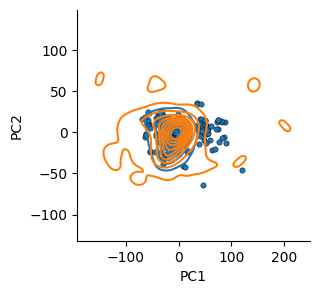

In [123]:
fig, ax = plt.subplots(1, 1, figsize=(3,3))
df = pd.read_pickle('coord_matrix_exp.pkl')

# learn space based on experimental structures
coord_matrix_exp = df.iloc[:,1:].to_numpy()
pca = PCA(n_components=2)
pcs = pca.fit_transform(coord_matrix_exp)

df_pca = pd.DataFrame()
df_pca['PC1'] = pcs[:,0]
df_pca['PC2'] = pcs[:,1]
sns.scatterplot(df_pca, x='PC1', y='PC2', ax=ax, edgecolor='black', s=15)


# project models into experimental space
topdirs = ['benchmark', 'benchmark-msa']

for topdir in topdirs:
    df = pd.read_pickle(f'{topdir}/coord_matrix.pkl')
    coord_matrix = df.iloc[:,1:].to_numpy()
    pcs = pca.transform(coord_matrix)

    df_pca = pd.DataFrame()
    df_pca['PC1'] = pcs[:,0]
    df_pca['PC2'] = pcs[:,1]
    sns.kdeplot(df_pca, x='PC1', y='PC2', ax=ax)

    #ax.legend(bbox_to_anchor=(1,1), frameon=False, loc='upper left')
    #ax.set_xlim(-190, 190)
    #ax.set_ylim(-60, 60)
sns.despine()



# IMMREP23

In [ ]:
df = pd.read_csv('IMMREP23_unseen.csv')
df = df.rename(columns={'model':'epitope', 'epitope':'peptide', 'MHC':'MHC_allele_a'})
df = df.drop(columns=['MHC_class'])
df['MHC_allele_a'] = 'HLA_' + df['MHC_allele_a']
df = df[df['peptide'].isin(['SALPTNADLY', 'TDLGQNLLY', 'VSDGGPNLY'])]
df = df.sort_values(by='peptide')
df['id'] = [f'tcr_{i:04}' for i in range(len(df))]
# move 'id' to the first column position
df.insert(0, 'id', df.pop('id'))

genes = ['TRAV', 'TRAJ', 'TRBV', 'TRBJ']
for g in genes:
    df[g] = df[g].str.split('*').str[0]

df.to_csv('IMMREP23_unseen_clean.csv')

,id,epitope,cdr3_TRA,cdr3_TRB,TRAV,TRAJ,TRBV,TRBJ,species,MHC_allele_a,peptide,Label
0,tcr_0000,A0101_SALPTNADLY,CAVGDNFNKFYF,CASAPTSAMGEQYF,TRAV8-3,TRAJ21,TRBV28,TRBJ2-7,HomoSapiens,HLA_A0101,SALPTNADLY,0
452,tcr_0001,A0101_SALPTNADLY,CAVRGSNYQLIW,CASSPHSYEQYF,TRAV21,TRAJ33,TRBV5-4,TRBJ2-7,HomoSapiens,HLA_A0101,SALPTNADLY,0
129,tcr_0002,A0101_SALPTNADLY,CAYRSAVGSQGNLIF,CAISELGGGSNTEAFF,TRAV38-2/DV8,TRAJ42,TRBV10-3,TRBJ1-1,HomoSapiens,HLA_A0101,SALPTNADLY,1
626,tcr_0003,A0101_SALPTNADLY,CVARGGATNKLIF,CASSLIFAGRGAEAFF,TRAV12-1,TRAJ32,TRBV12-4,TRBJ1-1,HomoSapiens,HLA_A0101,SALPTNADLY,0
126,tcr_0004,A0101_SALPTNADLY,CAVSPGTRLMF,CQQFSGQGNLRAVF,TRAV21,TRAJ31,TRBV12-3,TRBJ2-7,HomoSapiens,HLA_A0101,SALPTNADLY,0
